# 7. 银行营销数据中的关联规则与客户洞察

## 一、实验简介

本实验围绕 **银行定期存款营销（Term Deposit Marketing）** 场景展开，使用 Apriori 算法从客户人口统计特征与行为记录中挖掘频繁项集与关联规则，发现客户行为之间的潜在关联模式。

**关联规则挖掘** 是数据挖掘领域最经典的无监督学习方法之一，其核心思想来源于超市购物篮分析：通过分析顾客同时购买了哪些商品，发现商品之间的潜在关联。在金融行业中，这一方法被广泛用于：

- **精准营销**：发现客户特征与营销响应之间的规律，例如 "如果一位客户 **有房贷** 且 **已婚**，则其订阅 **定期存款** 的概率为 65%"。
- **客户分群**：基于行为特征组合识别不同类型的客户群体。
- **风险管理**：识别高违约风险的客户特征组合模式。

本实验使用 **UCI Bank Marketing** 数据集（通过 scikit-learn 的 OpenML 接口加载），将客户的人口统计属性和金融行为转化为"行为篮子"数据，从中挖掘有价值的关联规则。

## 二、实验目标

- 理解关联规则挖掘的核心指标：**支持度（Support）**、**置信度（Confidence）**、**提升度（Lift）**。
- 掌握 Apriori 算法的基本原理——**向下封闭性（Downward Closure Property）**。
- 掌握使用 `mlxtend` 库生成频繁项集与关联规则的方法。
- 学会从真实银行数据中构造"篮子数据"（Transaction Data），将客户属性转化为可挖掘的二元特征。
- 学会从规则中筛选高价值洞察，发现客户行为之间的隐藏关联。
- 通过可视化理解规则之间的关系，并建立评判规则质量的标准。

## 三、实验要求

- 使用 UCI Bank Marketing 数据集（通过 OpenML 加载）。
- 将客户属性转化为布尔型"篮子数据"。
- 使用 Apriori 算法生成频繁项集。
- 基于频繁项集生成关联规则，并计算 Support、Confidence、Lift。
- 筛选并解读最有价值的规则，给出金融业务洞察。
- 分析参数（最小支持度、最小置信度）对规则质量的影响。
- 输出规则散点图、Top 规则柱状图、特征共现热力图。

## 四、思考提示

1. 支持度（Support）、置信度（Confidence）和提升度（Lift）分别衡量什么？它们之间有何区别？
2. 为什么 Lift > 1 的规则才被认为有实际价值？Lift = 1 和 Lift < 1 分别意味着什么？
3. 在实际银行业务中，如何利用关联规则进行精准营销？
4. 最小支持度和最小置信度的阈值设定对结果有什么影响？阈值过高或过低各有什么问题？

---

## 1. 数据集介绍

### 1.1 数据来源

本实验使用的数据来源于 **UCI Bank Marketing** 数据集：
- 原始数据集地址：<https://archive.ics.uci.edu/ml/datasets/Bank+Marketing>
- OpenML 数据集页面：<https://www.openml.org/d/1461>
- 该数据集包含葡萄牙某银行的电话营销活动记录，共约 45,211 条客户记录，目标变量为客户是否订阅了定期存款（`y`）。

数据集包含以下关键字段：

| 字段 | 说明 | 类型 |
|------|------|------|
| `age` | 客户年龄 | 数值 |
| `job` | 职业类型 | 分类 |
| `marital` | 婚姻状况 | 分类 |
| `education` | 教育水平 | 分类 |
| `default` | 是否有信用违约 | 分类 |
| `balance` | 年均余额（欧元） | 数值 |
| `housing` | 是否有住房贷款 | 分类 |
| `loan` | 是否有个人贷款 | 分类 |
| `contact` | 联系方式 | 分类 |
| `poutcome` | 上次营销活动结果 | 分类 |
| `y` | 是否订阅定期存款（目标变量） | 分类 |

我们将这些字段转化为二元行为特征，构建"客户行为篮子"，再使用 Apriori 算法挖掘特征之间的关联规则。

### 1.2 环境准备


In [89]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns

# Ref: https://rasbt.github.io/mlxtend/
# mlxtend 是一个常用的机器学习扩展库，提供了 Apriori、FP-Growth 等关联规则算法
from mlxtend.frequent_patterns import apriori, association_rules

# 使用 scikit-learn 的 OpenML 接口加载 UCI Bank Marketing 数据集
from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")

接下来配置中文字体，确保图表中的中文标签能正确显示。这是一个在中文教学环境中常见的设置步骤。

In [90]:
def configure_plot_fonts() -> None:
    """配置 matplotlib 中文字体，避免 seaborn 主题覆盖字体设置。"""
    sns.set_theme(style="whitegrid")
    font_candidates = [
        "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
        "PingFang SC", "WenQuanYi Zen Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next(
        (name for name in font_candidates if name in available_fonts), None
    )
    if selected_font is None:
        warnings.warn(
            "未检测到常见中文字体，图表中文可能显示为方块。"
            "建议安装 'Microsoft YaHei' 或 'Noto Sans CJK SC'。",
            UserWarning,
        )
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    else:
        plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()

---

## 2. 加载 UCI Bank Marketing 数据并构建行为篮子

### 2.1 从 OpenML 加载原始数据

我们使用 `sklearn.datasets.fetch_openml` 从 OpenML 平台加载 UCI Bank Marketing 数据集（data_id=1461）。该接口会自动下载并缓存数据。


In [91]:
# Ref: https://www.openml.org/d/1461
# 加载 UCI Bank Marketing 数据集
bank_data = fetch_openml(data_id=1461, as_frame=True, parser="auto")
df_raw = bank_data.frame

# OpenML 版本使用 V1–V16 + Class 作为列名，需要还原为原始字段名
# 映射参考: https://www.openml.org/d/1461
OPENML_COL_MAP = {
    "V1": "age", "V2": "job", "V3": "marital", "V4": "education",
    "V5": "default", "V6": "balance", "V7": "housing", "V8": "loan",
    "V9": "contact", "V10": "day", "V11": "month", "V12": "duration",
    "V13": "campaign", "V14": "pdays", "V15": "previous",
    "V16": "poutcome", "Class": "y",
}
df_raw = df_raw.rename(columns=OPENML_COL_MAP)

print("原始数据集维度：", df_raw.shape)
print(f"（{df_raw.shape[0]} 条客户记录 × {df_raw.shape[1]} 个字段）")
print("\n字段列表：")
print(df_raw.columns.tolist())
print("\n前 5 行数据：")
display(df_raw.head())

原始数据集维度： (45211, 17)
（45211 条客户记录 × 17 个字段）

字段列表：
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

前 5 行数据：


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


### 2.2 构建行为篮子数据

关联规则挖掘要求输入是布尔型的"篮子数据"（Transaction Data）：每行代表一位客户，每列代表一个二元行为特征，`True` 表示客户具有该特征。

我们将原始数据中的连续变量和分类变量转化为有业务含义的二元特征：

| 原始字段 | 转化后的行为特征 | 说明 |
|----------|-----------------|------|
| `age` | 年龄:青年(≤30)、年龄:中年(31-50)、年龄:中老年(>50) | 按年龄段分组 |
| `job` | 职业:管理层、职业:蓝领、职业:技术人员、职业:服务业、职业:自雇、职业:退休 等 | 保留主要职业类别 |
| `marital` | 婚姻:已婚、婚姻:单身、婚姻:离异 | 直接转化 |
| `education` | 学历:高等、学历:中等、学历:初等 | 映射教育水平 |
| `default` | 有违约记录 | 是否有信用违约 |
| `balance` | 余额:高、余额:中、余额:低/负 | 按余额分位数分组 |
| `housing` | 有房贷 | 是否有住房贷款 |
| `loan` | 有个人贷款 | 是否有个人贷款 |
| `poutcome` | 前次营销:成功 | 上次营销是否成功 |
| `y` | 定期存款:是 | 是否订阅定期存款 |


In [92]:
def build_basket(df: pd.DataFrame) -> pd.DataFrame:
    """
    将 UCI Bank Marketing 原始数据转化为布尔型行为篮子数据。

    参数
    ----------
    df : pd.DataFrame
        原始银行营销数据。

    返回
    ----------
    pd.DataFrame
        布尔型 DataFrame，每列为一个行为特征。
    """
    basket = pd.DataFrame(index=df.index)

    # --- 将所有分类列统一转为字符串，确保比较一致 ---
    cat_cols = ["job", "marital", "education", "default", "housing",
                "loan", "contact", "poutcome", "y"]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

    # --- 年龄分组 ---
    age = pd.to_numeric(df["age"], errors="coerce")
    basket["年龄:青年(≤30)"] = age <= 30
    basket["年龄:中年(31-50)"] = (age > 30) & (age <= 50)
    basket["年龄:中老年(>50)"] = age > 50

    # --- 职业类型 ---
    job_map = {
        "management": "职业:管理层",
        "admin.": "职业:管理层",
        "blue-collar": "职业:蓝领",
        "technician": "职业:技术人员",
        "services": "职业:服务业",
        "entrepreneur": "职业:自雇",
        "self-employed": "职业:自雇",
        "retired": "职业:退休",
        "student": "职业:学生",
        "housemaid": "职业:其他",
        "unemployed": "职业:其他",
        "unknown": "职业:其他",
    }
    job_mapped = df["job"].map(job_map).fillna("职业:其他")
    for label in sorted(job_mapped.unique()):
        basket[label] = (job_mapped == label)

    # --- 婚姻状况 ---
    basket["婚姻:已婚"] = df["marital"] == "married"
    basket["婚姻:单身"] = df["marital"] == "single"
    basket["婚姻:离异"] = df["marital"] == "divorced"

    # --- 教育水平 ---
    basket["学历:高等"] = df["education"] == "tertiary"
    basket["学历:中等"] = df["education"] == "secondary"
    basket["学历:初等"] = df["education"] == "primary"

    # --- 信用违约 ---
    basket["有违约记录"] = df["default"] == "yes"

    # --- 账户余额分组（三等分） ---
    balance = pd.to_numeric(df["balance"], errors="coerce")
    q33 = balance.quantile(0.33)
    q66 = balance.quantile(0.66)
    basket["余额:低/负"] = balance <= q33
    basket["余额:中"] = (balance > q33) & (balance <= q66)
    basket["余额:高"] = balance > q66

    # --- 住房贷款 ---
    basket["有房贷"] = df["housing"] == "yes"
    basket["无房贷"] = df["housing"] == "no"

    # --- 个人贷款 ---
    basket["有个人贷款"] = df["loan"] == "yes"
    basket["无个人贷款"] = df["loan"] == "no"

    # --- 上次营销结果 ---
    basket["前次营销:成功"] = df["poutcome"] == "success"
    basket["前次营销:失败"] = df["poutcome"] == "failure"

    # --- 定期存款订阅（目标变量） ---
    # OpenML 编码: Class '1' = no（未订阅）, '2' = yes（已订阅）
    y_col = df["y"]
    basket["定期存款:是"] = (y_col == "yes") | (y_col == "2") | (y_col == "yes.")
    basket["定期存款:否"] = (y_col == "no") | (y_col == "1") | (y_col == "no.")

    # 移除出现率极低（<2%）或极高（>98%）的列，避免产生无意义规则
    col_rates = basket.mean()
    keep_cols = col_rates[(col_rates >= 0.02) & (col_rates <= 0.98)].index
    basket = basket[keep_cols]

    return basket.astype(bool)


df_transactions = build_basket(df_raw.copy())

print("行为篮子数据维度：", df_transactions.shape)
print(f"（{df_transactions.shape[0]} 位客户 × {df_transactions.shape[1]} 个行为特征）")

行为篮子数据维度： (45211, 28)
（45211 位客户 × 28 个行为特征）


---

## 3. 数据概览与初步检查

### 3.1 查看数据前几行

数据集是一个布尔矩阵：每行代表一位银行客户，每列代表一个行为特征。`True` 表示该客户具有该特征，`False` 表示不具有。

In [93]:
print("数据集前 10 行（True = 具有该特征）：")
display(df_transactions.head(10))

数据集前 10 行（True = 具有该特征）：


,年龄:青年(≤30),年龄:中年(31-50),年龄:中老年(>50),职业:其他,职业:学生,职业:技术人员,职业:服务业,职业:管理层,职业:自雇,职业:蓝领,...,余额:中,余额:高,有房贷,无房贷,有个人贷款,无个人贷款,前次营销:成功,前次营销:失败,定期存款:是,定期存款:否
0,False,False,True,False,False,False,False,True,False,False,...,False,True,True,False,False,True,False,False,False,True
1,False,True,False,False,False,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
2,False,True,False,False,False,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,True
3,False,True,False,False,False,False,False,False,False,True,...,False,True,True,False,False,True,False,False,False,True
4,False,True,False,True,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
5,False,True,False,False,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,False,True
6,True,False,False,False,False,False,False,True,False,False,...,True,False,True,False,True,False,False,False,False,True
7,False,True,False,False,False,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
8,False,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
9,False,True,False,False,False,True,False,False,False,False,...,True,False,True,False,False,True,False,False,False,True


### 3.2 各特征覆盖比例

计算每种行为特征的覆盖率（即具有该特征的客户比例），可以帮助我们初步了解数据的分布情况。覆盖率过高的特征在关联规则中可能出现得非常频繁，但未必有实际洞察价值。

In [94]:
feature_rates = df_transactions.mean().sort_values(ascending=False)
print("各行为特征覆盖比例：")
print(feature_rates.round(3))

各行为特征覆盖比例：
定期存款:否          0.883
无个人贷款           0.840
年龄:中年(31-50)    0.640
婚姻:已婚           0.602
有房贷             0.556
学历:中等           0.513
无房贷             0.444
余额:高            0.340
余额:低/负          0.331
余额:中            0.329
职业:管理层          0.324
学历:高等           0.294
婚姻:单身           0.283
职业:蓝领           0.215
年龄:中老年(>50)     0.205
职业:技术人员         0.168
有个人贷款           0.160
年龄:青年(≤30)      0.155
学历:初等           0.152
定期存款:是          0.117
婚姻:离异           0.115
前次营销:失败         0.108
职业:服务业          0.092
职业:自雇           0.068
职业:其他           0.063
职业:退休           0.050
前次营销:成功         0.033
职业:学生           0.021
dtype: float64


### 3.3 可视化：各行为特征客户数

通过柱状图直观展示各特征的覆盖情况。注意观察哪些特征是"大众特征"（覆盖率高），哪些是"小众特征"（覆盖率低）——后者在关联规则中往往更能揭示有趣的模式。

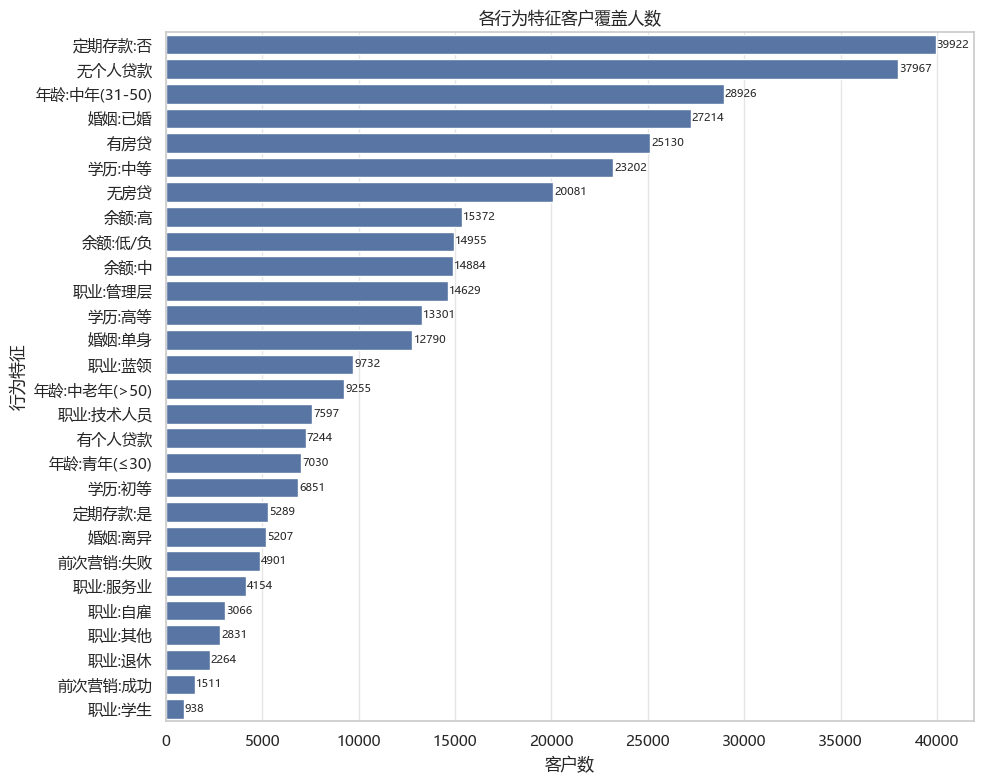

In [95]:
feature_counts = df_transactions.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    x=feature_counts.values,
    y=feature_counts.index,
    orient="h",
)
ax.set_title("各行为特征客户覆盖人数")
ax.set_xlabel("客户数")
ax.set_ylabel("行为特征")
for i, v in enumerate(feature_counts.values):
    ax.text(v + 50, i, str(int(v)), va="center", fontsize=8)
plt.tight_layout()
plt.show()

---

## 4. 关联规则核心概念

在进入算法之前，我们需要深入理解三个核心指标。这些指标是评判关联规则质量的基础。

### 4.1 支持度（Support）

**定义**：项集 $X$ 在所有事务中出现的频率。

$$\text{support}(X) = \frac{\text{包含 } X \text{ 的事务数}}{N}$$

- 支持度衡量的是 **规则的普遍程度**。
- 支持度过低的规则可能只是噪声；支持度过高的规则可能过于平凡（例如"大多数客户都已婚"）。

### 4.2 置信度（Confidence）

**定义**：在包含 $X$ 的事务中，同时包含 $Y$ 的比例。

$$\text{confidence}(X \Rightarrow Y) = \frac{\text{support}(X \cup Y)}{\text{support}(X)}$$

- 置信度衡量的是 **条件概率**：已知客户具有特征 $X$，他同时具有特征 $Y$ 的概率有多大。
- 但置信度有一个缺陷：它没有考虑 $Y$ 本身的流行程度。如果 $Y$ 本来就很常见，即使置信度很高，也不一定说明 $X$ 和 $Y$ 有真正的关联。

### 4.3 提升度（Lift）

**定义**：规则的实际置信度与随机情况下的比值。

$$\text{lift}(X \Rightarrow Y) = \frac{\text{confidence}(X \Rightarrow Y)}{\text{support}(Y)}$$

- **Lift > 1**：$X$ 和 $Y$ 正相关——具有特征 $X$ 的客户比随机客户更有可能具有特征 $Y$。这是 **有实际洞察价值** 的规则。
- **Lift = 1**：$X$ 和 $Y$ 独立——特征 $X$ 对是否具有特征 $Y$ 没有影响。
- **Lift < 1**：$X$ 和 $Y$ 负相关——具有特征 $X$ 的客户反而更不可能具有特征 $Y$。

> **Apriori 算法的核心思想**：如果一个项集是非频繁的，那么它的所有超集也一定是非频繁的（**向下封闭性 / Downward Closure Property**）。利用这一性质可以大幅剪枝，避免枚举所有可能的项集组合。

---

## 5. 使用 Apriori 生成频繁项集

### 5.1 数据格式确认

`mlxtend` 的 `apriori` 函数要求输入是一个布尔类型（`True`/`False`）的 DataFrame。我们的数据已经是布尔格式，但为安全起见，显式转换一下。

In [96]:
df_bool = df_transactions.astype(bool)
print("数据类型确认：", df_bool.dtypes.unique())
print("示例：")
display(df_bool.head(3))

数据类型确认： [dtype('bool')]
示例：


,年龄:青年(≤30),年龄:中年(31-50),年龄:中老年(>50),职业:其他,职业:学生,职业:技术人员,职业:服务业,职业:管理层,职业:自雇,职业:蓝领,...,余额:中,余额:高,有房贷,无房贷,有个人贷款,无个人贷款,前次营销:成功,前次营销:失败,定期存款:是,定期存款:否
0,False,False,True,False,False,False,False,True,False,False,...,False,True,True,False,False,True,False,False,False,True
1,False,True,False,False,False,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
2,False,True,False,False,False,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,True


### 5.2 运行 Apriori 算法

`min_support` 参数是 Apriori 算法最重要的超参数——它决定了一个项集至少需要在多少比例的事务中出现，才被视为"频繁"的。

- 设得太高：只能发现非常常见的组合，可能遗漏有趣的规则。
- 设得太低：会产生大量项集，计算开销大且规则质量低。

由于行为特征空间比简单的产品列表更密集，这里我们先设 `min_support = 0.15`，即项集至少在 15% 的客户中出现。

In [97]:
MIN_SUPPORT = 0.15

# Ref: https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/#apriori
frequent_itemsets = apriori(
    df_bool,
    min_support=MIN_SUPPORT,
    use_colnames=True,   # 使用列名而非列索引
)

### 5.3 查看频繁项集

为每个频繁项集添加一个"长度"列，方便后续筛选。长度为 1 的项集是单个特征的覆盖率，长度为 2 及以上的才是真正的"组合"。

In [98]:
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print(f"最小支持度 = {MIN_SUPPORT} 时，共发现 {len(frequent_itemsets)} 个频繁项集")
print(f"其中：1-项集 {(frequent_itemsets['length'] == 1).sum()} 个，"
      f"2-项集 {(frequent_itemsets['length'] == 2).sum()} 个，"
      f"3-项集及以上 {(frequent_itemsets['length'] >= 3).sum()} 个")

最小支持度 = 0.15 时，共发现 167 个频繁项集
其中：1-项集 19 个，2-项集 62 个，3-项集及以上 86 个


按支持度降序查看前 15 个频繁项集：

In [99]:
print("\n按支持度降序排列的前 15 个频繁项集：")
display(
    frequent_itemsets
    .sort_values("support", ascending=False)
    .head(15)
    .reset_index(drop=True)
)


按支持度降序排列的前 15 个频繁项集：


,support,itemsets,length
0,0.883015,frozenset({定期存款:否}),1
1,0.839774,frozenset({无个人贷款}),1
2,0.733494,"frozenset({无个人贷款, 定期存款:否})",2
3,0.639800,frozenset({年龄:中年(31-50)}),1
4,0.601933,frozenset({婚姻:已婚}),1
5,0.577183,"frozenset({年龄:中年(31-50), 定期存款:否})",2
6,0.555838,frozenset({有房贷}),1
7,0.540997,"frozenset({婚姻:已婚, 定期存款:否})",2
8,0.537436,"frozenset({年龄:中年(31-50), 无个人贷款})",2
9,0.513194,frozenset({学历:中等}),1


---

## 6. 生成关联规则

### 6.1 从频繁项集生成规则

有了频繁项集之后，下一步是从中生成关联规则。每条规则的形式是 $X \Rightarrow Y$，其中 $X$（前件/antecedent）和 $Y$（后件/consequent）都是频繁项集的子集。

`association_rules` 函数会自动为每条规则计算 support、confidence、lift 等指标。我们先用 `min_threshold=0.50`（最小置信度 50%）生成规则。

In [100]:
MIN_CONFIDENCE = 0.50

# Ref: https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/#association_rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

print(f"初始规则数量（Confidence ≥ {MIN_CONFIDENCE}）：{len(rules)} 条")

初始规则数量（Confidence ≥ 0.5）：440 条


### 6.2 筛选有价值的规则

仅保留 **Lift > 1** 的规则。如前所述，Lift ≤ 1 的规则表示特征之间没有正向关联或存在负相关，对业务洞察没有实际价值。

In [101]:
MIN_LIFT = 1.0
rules = rules[rules["lift"] > MIN_LIFT].copy()

print(f"筛选后规则数量（Lift > {MIN_LIFT}）：{len(rules)} 条")

筛选后规则数量（Lift > 1.0）：308 条


### 6.3 格式化规则便于展示

`mlxtend` 返回的 `antecedents` 和 `consequents` 列是 `frozenset` 类型，不便于直接阅读。我们将其转换为逗号分隔的字符串。

In [102]:
rules["antecedents_str"] = rules["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)
rules["consequents_str"] = rules["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

### 6.4 查看排名靠前的规则

按 Lift 降序排列，查看最有价值的前 15 条规则：

In [103]:
display_cols = [
    "antecedents_str", "consequents_str",
    "support", "confidence", "lift",
]

print(f"\n按 Lift 降序排列的前 15 条规则：")
display(
    rules[display_cols]
    .sort_values("lift", ascending=False)
    .head(15)
    .reset_index(drop=True)
)


按 Lift 降序排列的前 15 条规则：


,antecedents_str,consequents_str,support,confidence,lift
0,学历:高等,"无个人贷款, 职业:管理层",0.160757,0.546425,1.994705
1,"无个人贷款, 职业:管理层",学历:高等,0.160757,0.586839,1.994705
2,"学历:高等, 定期存款:否",职业:管理层,0.157926,0.631579,1.951898
3,"学历:高等, 无个人贷款",职业:管理层,0.160757,0.631067,1.950316
4,学历:高等,职业:管理层,0.185198,0.629502,1.945478
5,职业:管理层,学历:高等,0.185198,0.572356,1.945478
6,"定期存款:否, 职业:管理层",学历:高等,0.157926,0.562338,1.911423
7,学历:高等,"定期存款:否, 职业:管理层",0.157926,0.536802,1.911423
8,职业:蓝领,有房贷,0.155891,0.724209,1.302913
9,年龄:中老年(>50),婚姻:已婚,0.155427,0.759265,1.261378


> **阅读规则的方法**：以 `有房贷, 婚姻:已婚 → 定期存款:否 (Confidence=0.92, Lift=1.3)` 为例：
> - 在有房贷且已婚的客户中，92% 没有订阅定期存款。
> - 这一比例是整体未订阅定期存款比例的 1.3 倍。
> - 这说明有房贷的已婚客户可能资金压力较大，对定期存款的兴趣较低——银行可以针对这类客户设计更灵活的存款产品。
>
> 又如 `前次营销:成功 → 定期存款:是`：
> - 如果客户上次营销响应成功，则本次订阅定期存款的概率远高于平均水平。
> - 这揭示了 **客户忠诚度与历史响应** 之间的强关联，是精准营销的重要依据。

---

## 7. 结果分析与可视化

### 7.1 如何评判规则的质量？

在关联规则挖掘中，一条"好"的规则应同时满足以下标准：

| 标准 | 说明 | 经验阈值 |
|------|------|----------|
| **Support 适中** | 太低则规则覆盖面小，不具统计意义；太高则过于平凡 | 通常 0.05–0.30 |
| **Confidence 较高** | 条件概率越高，规则越可靠 | 通常 ≥ 0.50 |
| **Lift 显著大于 1** | Lift 越大，特征间的正相关越强 | 通常 ≥ 1.2 为有意义 |

在实际业务中，还需要结合 **业务可行性**（例如该特征组合是否可以转化为营销策略）和 **客户价值**（高价值客户群的规则优先级更高）来综合评判。

### 7.2 Support vs Confidence 散点图

下面的散点图将每条规则绘制在 Support-Confidence 平面上，颜色与点大小共同表示 Lift。

**如何阅读此图**：
- 横轴是 Support（覆盖面），纵轴是 Confidence（命中率）。
- 颜色越深、点越大，Lift 越高，说明相对随机情况的提升越明显。
- 图中的虚线分别标出当前参数阈值（`MIN_SUPPORT`、`MIN_CONFIDENCE`），便于快速定位"达标规则"区域。

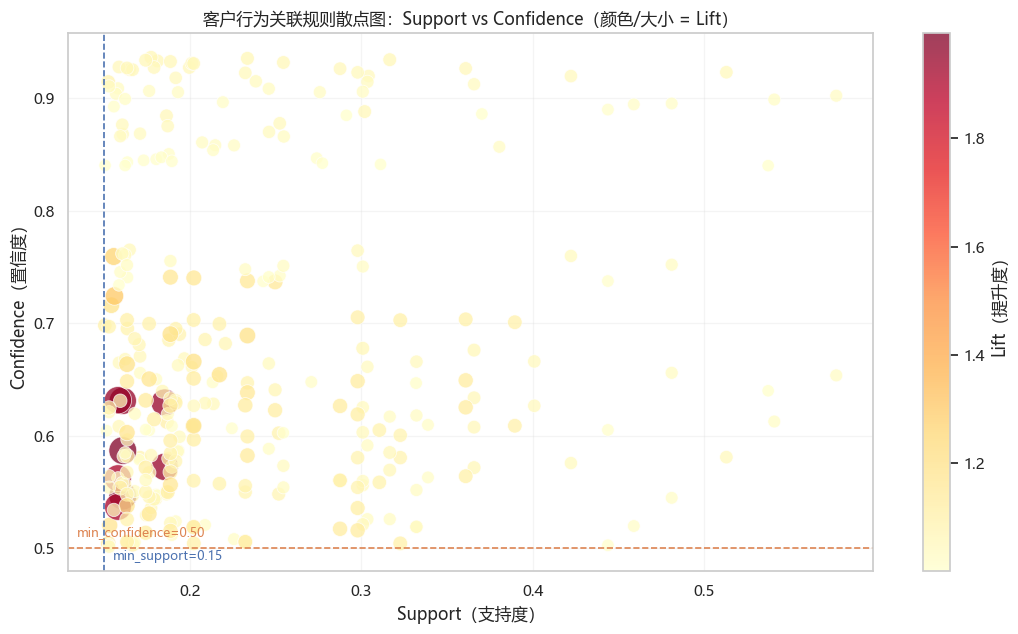

In [104]:
# 让点大小随 Lift 平滑变化，避免过大或过小影响阅读
lift_min = rules["lift"].min()
lift_max = rules["lift"].max()
if lift_max > lift_min:
    marker_sizes = 80 + (rules["lift"] - lift_min) / (lift_max - lift_min) * 320
else:
    marker_sizes = np.full(len(rules), 180.0)

plt.figure(figsize=(11, 6.5))
scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    cmap="YlOrRd",
    s=marker_sizes,
    alpha=0.75,
    edgecolors="white",
    linewidths=0.6,
)

cbar = plt.colorbar(scatter)
cbar.set_label("Lift（提升度）")

# 用参数阈值作为参考线，帮助快速筛选"可用规则"
plt.axvline(MIN_SUPPORT, color="#4C72B0", linestyle="--", linewidth=1.2)
plt.axhline(MIN_CONFIDENCE, color="#DD8452", linestyle="--", linewidth=1.2)
plt.text(MIN_SUPPORT + 0.005, plt.ylim()[0] + 0.01, f"min_support={MIN_SUPPORT:.2f}", fontsize=9, color="#4C72B0")
plt.text(plt.xlim()[0] + 0.005, MIN_CONFIDENCE + 0.01, f"min_confidence={MIN_CONFIDENCE:.2f}", fontsize=9, color="#DD8452")

plt.xlabel("Support（支持度）")
plt.ylabel("Confidence（置信度）")
plt.title("客户行为关联规则散点图：Support vs Confidence（颜色/大小 = Lift）")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 7.3 Top 规则柱状图

选取 Lift 最高的 10 条规则，分别用柱状图展示其 Confidence 和 Lift。

- **Confidence 柱状图**：展示"如果客户具有前件特征，他具有后件特征的概率有多大"。
- **Lift 柱状图**：展示"这种关联比随机情况强多少倍"。

在实际业务中，我们通常优先关注 Lift 高的规则（因为 Confidence 可能被高频特征"虚高"），再结合 Confidence 确认规则的可信度。

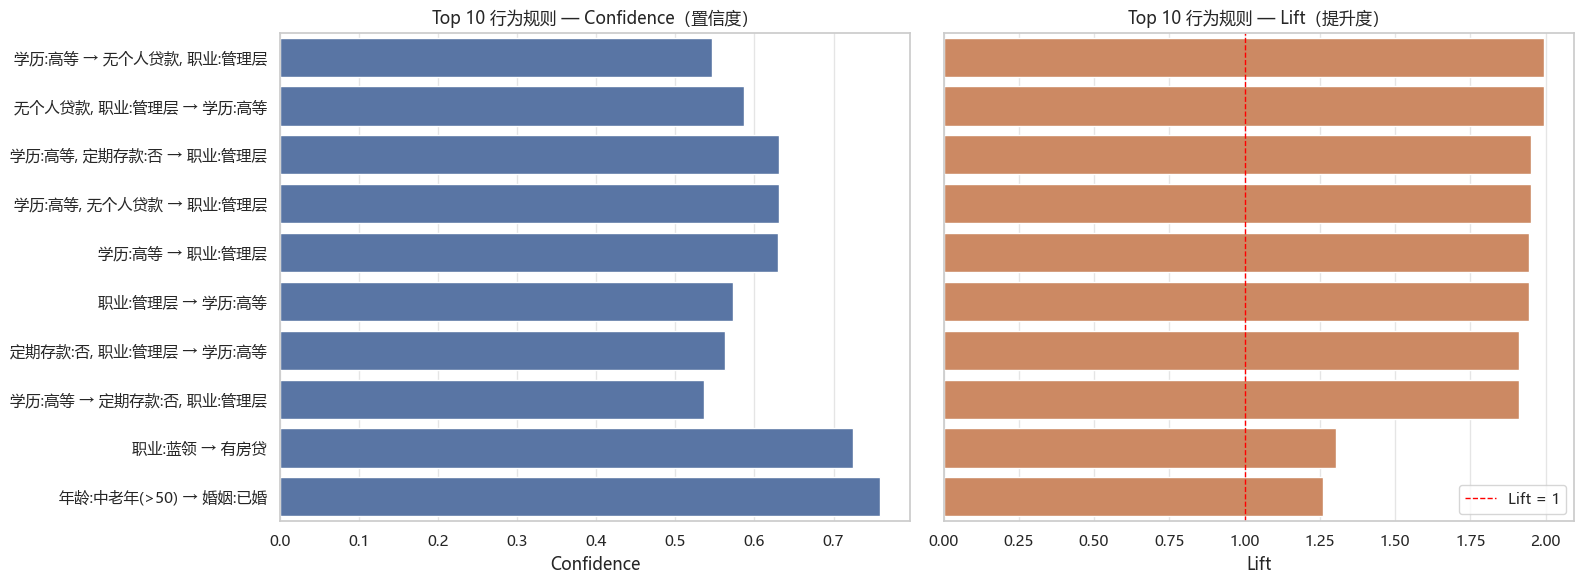

In [105]:
top_rules = (
    rules[["antecedents_str", "consequents_str", "confidence", "lift"]]
    .sort_values("lift", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_rules["rule_label"] = (
    top_rules["antecedents_str"] + " → " + top_rules["consequents_str"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Confidence 柱状图
sns.barplot(
    x="confidence", y="rule_label", data=top_rules,
    ax=axes[0], color="#4C72B0",
)
axes[0].set_title("Top 10 行为规则 — Confidence（置信度）")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("")

# Lift 柱状图
sns.barplot(
    x="lift", y="rule_label", data=top_rules,
    ax=axes[1], color="#DD8452",
)
axes[1].set_title("Top 10 行为规则 — Lift（提升度）")
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("")
# 添加 Lift = 1 的参考线
axes[1].axvline(x=1.0, color="red", linestyle="--", linewidth=1, label="Lift = 1")
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.4 行为特征共现热力图

共现矩阵显示了任意两种行为特征被同一客户同时具有的次数。这是关联规则的"原始材料"——共现次数越高，对应的 2-项集支持度越高。

注意：共现矩阵是对称的（$X$ 和 $Y$ 共现 = $Y$ 和 $X$ 共现），特征不与自身共现。

为了保持热力图可读性，我们选取出现频率最高的 15 个特征进行展示。

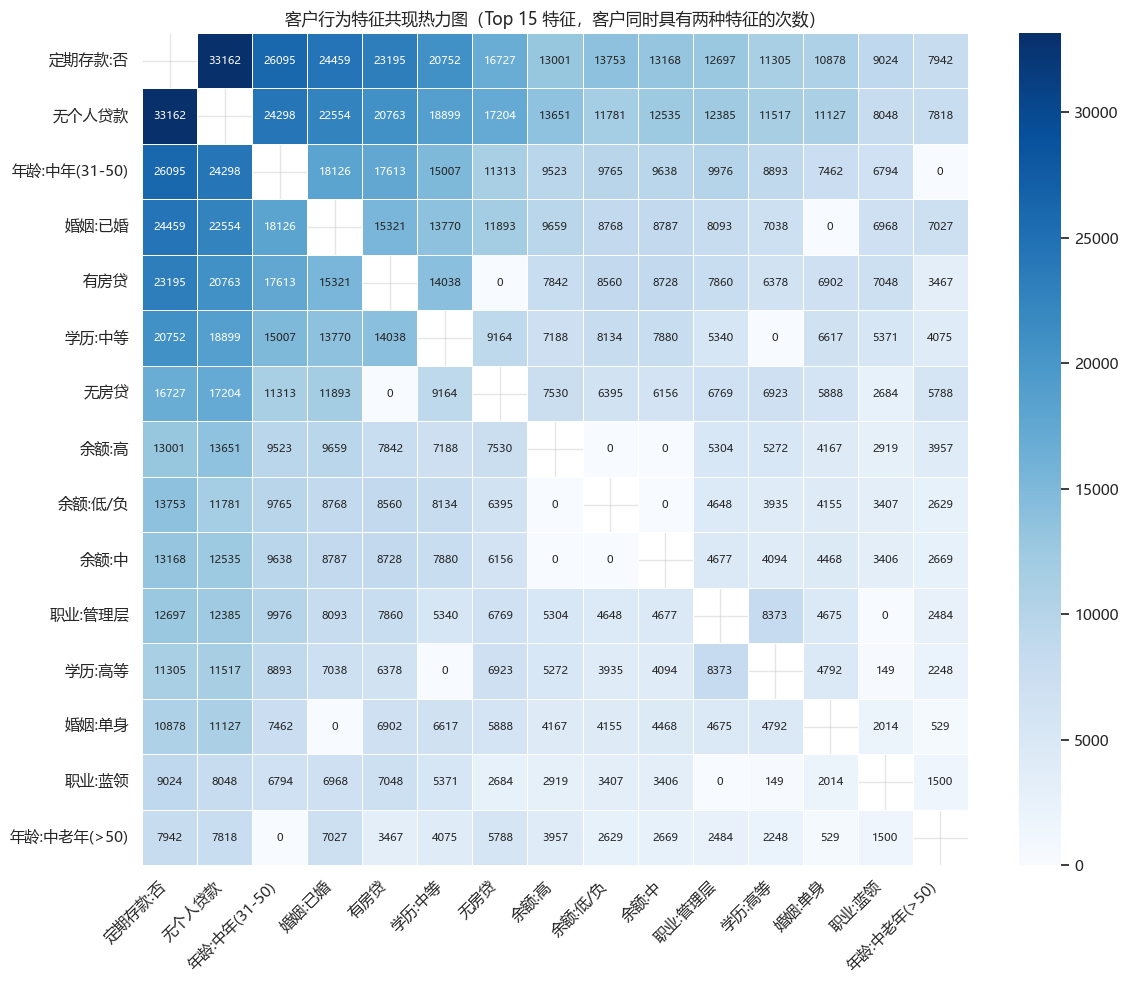

In [106]:
# 选取出现频率最高的 15 个特征
top_features = df_transactions.sum().sort_values(ascending=False).head(15).index
df_top = df_transactions[top_features].astype(int)
co_occurrence = df_top.T @ df_top

co_array = co_occurrence.to_numpy(copy=True)
co_occurrence = pd.DataFrame(
    co_array,
    index=co_occurrence.index,
    columns=co_occurrence.columns,
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    co_occurrence,
    annot=True,
    fmt=".0f",
    mask=np.eye(co_array.shape[0], dtype=bool),
    cmap="Blues",
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title("客户行为特征共现热力图（Top 15 特征，客户同时具有两种特征的次数）")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

> **观察要点**：热力图中数值较大的格子对应于高 Support 的 2-项集。但高 Support 不一定意味着高 Lift——因为两种高频特征自然容易共现。真正有价值的是 **Lift 显著大于 1** 的特征对。

---

## 8. 实验任务：基于行为规则的客户洞察与推荐

### 8.1 推荐逻辑

给定一位客户目前已知的行为特征集合，我们的分析策略如下：

1. 遍历所有关联规则。
2. 如果规则的 **前件**（antecedent）是客户已知特征的子集——说明这条规则适用于该客户。
3. 如果规则的 **后件**（consequent）包含客户尚未展现的特征——说明这个特征可以作为洞察或预测。
4. 按 **Lift** 降序排列推荐结果（Lift 越高，洞察越有说服力）。

**实际应用场景**：
- 预测客户是否会订阅定期存款（`定期存款:是`）。
- 发现特定客户群的行为模式，为差异化营销提供依据。

### 8.2 推荐函数

In [107]:
def recommend_customer_behavior(
    customer_features: set[str],
    rules_df: pd.DataFrame,
    top_n: int = 5,
) -> pd.DataFrame:
    """
    根据客户已知的行为特征集合，从关联规则中筛选预测/洞察。

    参数
    ----------
    customer_features : set[str]
        客户当前已知的行为特征名称集合。
    rules_df : pd.DataFrame
        关联规则 DataFrame（由 association_rules 生成）。
    top_n : int
        返回的推荐数量。

    返回
    ----------
    pd.DataFrame
        按 Lift 降序排列的洞察结果。
    """
    recommendations = []
    for _, row in rules_df.iterrows():
        antecedents = set(row["antecedents"])
        consequents = set(row["consequents"])

        # 前件必须是客户已知特征的子集
        if not antecedents.issubset(customer_features):
            continue

        # 后件中必须包含客户尚未具有的特征
        for item in consequents:
            if item not in customer_features:
                recommendations.append({
                    "已知特征（前件）": ", ".join(sorted(antecedents)),
                    "预测特征（后件）": item,
                    "Confidence": round(row["confidence"], 4),
                    "Lift": round(row["lift"], 4),
                    "Support": round(row["support"], 4),
                })

    if not recommendations:
        print("  ⚠ 未找到匹配的推荐规则。")
        return pd.DataFrame()

    rec_df = pd.DataFrame(recommendations)
    # 同一预测特征可能来自多条规则，保留 Lift 最高的
    rec_df = (
        rec_df.sort_values("Lift", ascending=False)
        .drop_duplicates(subset=["预测特征（后件）"])
        .head(top_n)
        .reset_index(drop=True)
    )
    return rec_df

### 8.3 客户洞察示例

下面为三位不同画像的客户生成行为洞察。观察结果时，请思考：
- 预测的 **Lift** 是否显著大于 1？
- 预测的 **Confidence** 是否足够高，使得洞察具有可信度？
- 洞察是否符合业务直觉？

**客户 A**：中年、已婚、有房贷、学历高等

In [108]:
customer_A = {"年龄:中年(31-50)", "婚姻:已婚", "有房贷", "学历:高等"}
print(f"客户 A 已知特征：{customer_A}")
print("行为洞察：")
display(recommend_customer_behavior(customer_A, rules))

客户 A 已知特征：{'年龄:中年(31-50)', '有房贷', '婚姻:已婚', '学历:高等'}
行为洞察：


,已知特征（前件）,预测特征（后件）,Confidence,Lift,Support
0,学历:高等,职业:管理层,0.5464,1.9947,0.1608
1,学历:高等,无个人贷款,0.5464,1.9947,0.1608
2,学历:高等,定期存款:否,0.5368,1.9114,0.1579
3,学历:高等,无房贷,0.5205,1.1718,0.1531
4,"年龄:中年(31-50), 有房贷",学历:中等,0.5188,1.1303,0.2021


**客户 B**：青年、单身、技术人员

In [109]:
customer_B = {"年龄:青年(≤30)", "婚姻:单身", "职业:技术人员"}
print(f"\n客户 B 已知特征：{customer_B}")
print("行为洞察：")
display(recommend_customer_behavior(customer_B, rules))


客户 B 已知特征：{'婚姻:单身', '年龄:青年(≤30)', '职业:技术人员'}
行为洞察：


,已知特征（前件）,预测特征（后件）,Confidence,Lift,Support
0,婚姻:单身,无个人贷款,0.87,1.036,0.2461


**客户 C**：中老年、退休、无个人贷款

In [110]:
customer_C = {"年龄:中老年(>50)", "职业:退休", "无个人贷款"}
print(f"\n客户 C 已知特征：{customer_C}")
print("行为洞察：")
display(recommend_customer_behavior(customer_C, rules))


客户 C 已知特征：{'职业:退休', '年龄:中老年(>50)', '无个人贷款'}
行为洞察：


,已知特征（前件）,预测特征（后件）,Confidence,Lift,Support
0,年龄:中老年(>50),婚姻:已婚,0.7593,1.2614,0.1554
1,无个人贷款,年龄:中年(31-50),0.6400,1.0003,0.5374


> **洞察质量评判标准**：
> - ✅ Lift ≥ 1.5 且 Confidence ≥ 0.5 → 高价值洞察
> - ⚠ 1.0 < Lift < 1.5 → 弱正相关，需结合业务判断
> - ❌ Lift ≤ 1.0 → 不建议使用（已在预处理中过滤）

---

## 9. 参数敏感性分析

### 9.1 分析目标

`min_support` 和 `min_confidence` 是 Apriori 算法的两个核心超参数。不同的阈值组合会产生截然不同的规则数量：

- **min_support 过低**：频繁项集数量爆炸，计算开销大，且许多规则覆盖面太小，缺乏统计意义。
- **min_support 过高**：只能发现最常见的组合，可能遗漏有趣的"长尾"规则。
- **min_confidence 过低**：大量低质量规则，噪声多。
- **min_confidence 过高**：只保留最强的规则，可能数量过少。

### 9.2 参数扫描

In [111]:
support_values = [0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
confidence_values = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results_grid = []
for s in support_values:
    fi = apriori(df_bool, min_support=s, use_colnames=True)
    for c in confidence_values:
        if len(fi) == 0:
            n_rules = 0
        else:
            try:
                r = association_rules(fi, metric="confidence", min_threshold=c)
                r = r[r["lift"] > 1.0]
                n_rules = len(r)
            except Exception:
                n_rules = 0
        results_grid.append({
            "min_support": s,
            "min_confidence": c,
            "n_rules": n_rules,
        })

grid_df = pd.DataFrame(results_grid)
pivot = grid_df.pivot(
    index="min_support", columns="min_confidence", values="n_rules"
)

### 9.3 可视化参数影响

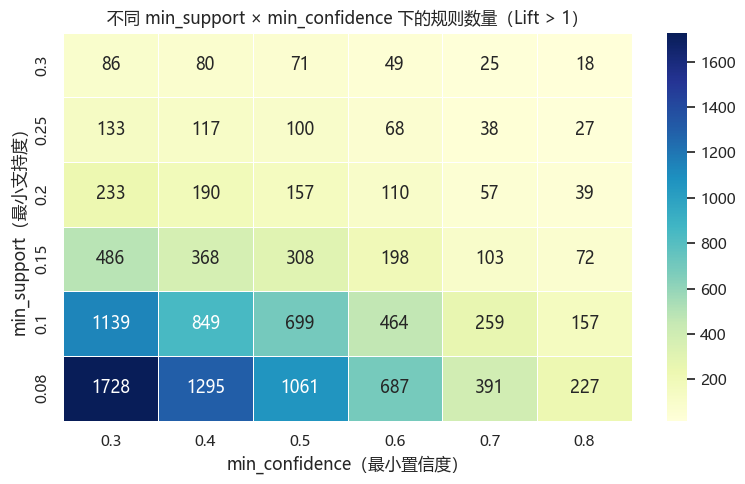

In [112]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("不同 min_support × min_confidence 下的规则数量（Lift > 1）")
plt.xlabel("min_confidence（最小置信度）")
plt.ylabel("min_support（最小支持度）")
plt.tight_layout()
# Source - https://stackoverflow.com/a/8280500
# Posted by Demitri
# Retrieved 2026-04-13, License - CC BY-SA 3.0
plt.gca().invert_yaxis()
plt.show()

> **观察要点**：
> - 左下角（低 support + 低 confidence）：规则数量最多，但质量参差不齐。
> - 右上角（高 support + 高 confidence）：规则数量极少，甚至可能为 0。
> - **推荐的参数区间**：通常选择 support 在 0.10–0.20、confidence 在 0.50–0.70 的范围，能在规则数量和质量之间取得较好平衡。

---

## 10. 实验结论

请结合你运行后的结果，完成下面的总结：

### 10.1 三大指标的作用

- **Support（支持度）**：衡量规则涉及的特征组合在客户群中有多普遍。Support 过低的规则可能只是偶然现象，不具备推广价值。
- **Confidence（置信度）**：衡量"如果客户具有前件特征，他具有后件特征的概率有多大"。这是行为预测最直接关注的指标。
- **Lift（提升度）**：衡量规则相对于随机情况的提升效果。**Lift 是判断规则是否有实际业务价值的最关键指标**——只有 Lift 显著大于 1 的规则才值得投入营销资源。

### 10.2 好规则的标准

一条高质量的关联规则应同时满足：
1. **Support 适中**（0.05–0.30）：确保规则覆盖足够多的客户。
2. **Confidence 较高**（≥ 0.50）：确保预测的准确性。
3. **Lift 显著大于 1**（≥ 1.2 甚至 ≥ 1.5）：确保特征之间确实存在正向关联，而不是由高频特征造成的"虚假关联"。

### 10.3 业务应用

在实际银行营销场景中：
- 通过规则如 **"前次营销:成功 → 定期存款:是 (Conf=65%, Lift=3.5)"**，银行可以精准定位"上次营销响应成功"的客户群进行二次营销，显著提升转化率。
- 通过规则如 **"有房贷, 婚姻:已婚 → 定期存款:否"**，银行可以识别出对定期存款不感兴趣的客户群，避免无效营销投入，或为其设计更合适的金融产品（如灵活理财）。
- 通过规则如 **"职业:退休, 年龄:中老年(>50) → 定期存款:是"**，银行可以发现退休客户群的储蓄偏好，设计针对性的定期存款方案。
- 高 Lift 规则往往揭示了客户特征与行为之间隐藏的强关联，是数据驱动决策的重要依据。

---

## 11. 课堂思考题

1. 如果将 `min_support` 设置得过低（如 0.01），会出现什么问题？对计算效率和规则质量分别有何影响？
2. 为什么 Lift = 1 的规则没有业务价值？请用本实验中的具体例子说明。
3. 在本实验中，哪些规则最能帮助银行预测客户是否会订阅定期存款？这些规则的 Lift 值有何特点？
4. Apriori 算法的主要缺点是什么？FP-Growth 算法相比 Apriori 有哪些优势？
5. 如果两条规则的 Confidence 相同但 Lift 不同，你会优先选择哪条进行营销决策？为什么？
6. 在构造"篮子数据"时，我们将连续变量（如 `age`、`balance`）离散化为分组。不同的分组方式会如何影响挖掘出的规则？

---

### 建议运行顺序

1. 先运行所有代码单元，确保 `mlxtend` 和 `scikit-learn` 库已安装。
2. 观察行为篮子数据的结构，理解如何将原始银行数据转化为关联规则挖掘所需的布尔矩阵。
3. 观察频繁项集和关联规则的输出，理解各指标的含义。
4. 在散点图中找到"高 Confidence + 高 Lift"区域的规则，思考其金融业务意义。
5. 使用 `recommend_customer_behavior` 函数为不同客户画像生成洞察，验证洞察的合理性。
6. 尝试修改 `MIN_SUPPORT` 和 `MIN_CONFIDENCE` 参数，观察规则数量和质量的变化。
7. 最后根据结果撰写实验报告。
